In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn import datasets

In [3]:
iris = datasets.load_iris()
X = iris.data[:,[2,3]]
y = iris.target

In [4]:
print('Class Labels: ', np.unique(y))

Class Labels:  [0 1 2]


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 1, stratify = y)

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
sc = StandardScaler()

In [9]:
sc.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [10]:
X_train_scaled = sc.transform(X_train)
X_test_scaled = sc.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

In [12]:
lr = LogisticRegression(C=100.0, solver = 'lbfgs')

In [13]:
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
from matplotlib.colors import ListedColormap
def plot_decision_regions(X, y, classifier, test_idx = None, resolution = 0.02):
    #Set up markers and colors and color map

    markers = ('o','s','^','v', '<')
    colors = ('red', 'green', 'blue', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() -1, X[:, 0].max() +1
    x2_min, x2_max = X[:, 1].min() -1, X[:, 0].max() +1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha = 0.3, cmap = cmap)
    plt.xlim(xx1.min(), xx2.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x = X[y == cl, 0],
                    y = X[y == cl, 1],
                    alpha = 0.8,
                    c = colors[idx],
                    label=f'Class{cl}',
                    edgecolor = 'black')
    

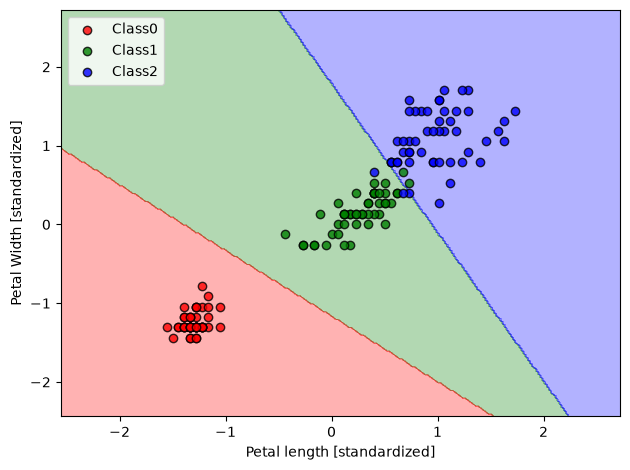

In [16]:
lr = LogisticRegression(C= 100.0, solver = 'lbfgs')
lr.fit(X_train_scaled, y_train)

X_combined_std = np.vstack((X_train_scaled, X_test_scaled))
y_combined = np.hstack((y_train,y_test))
plot_decision_regions(X_combined_std, y_combined, classifier = lr, test_idx = range(105,150))

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal Width [standardized]')

plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

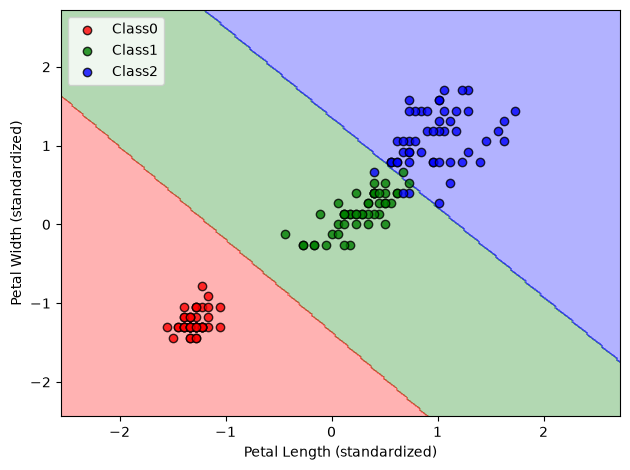

In [18]:
from sklearn.svm import SVC 
svm = SVC(kernel = 'linear', C = 1.0, random_state = 1)
svm.fit(X_train_scaled, y_train)

plot_decision_regions(X_combined_std, y_combined, classifier = svm, test_idx = range(105,150))

plt.xlabel('Petal Length (standardized)')
plt.ylabel('Petal Width (standardized)')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

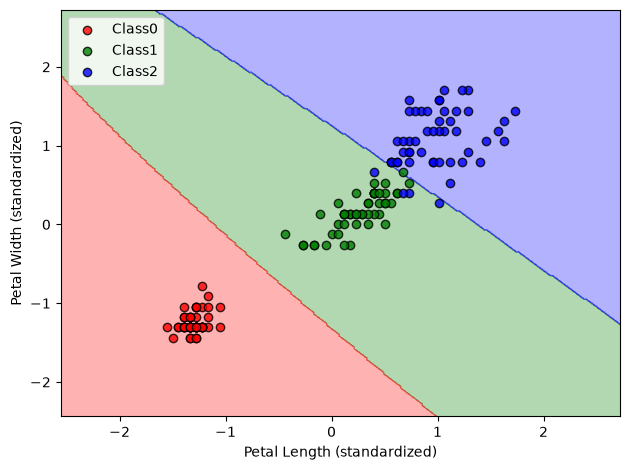

In [21]:
from sklearn.svm import SVC
svm = SVC(kernel = 'rbf', random_state = 1, gamma = 0.1, C = 1.0)
svm.fit(X_train_scaled, y_train)
plot_decision_regions(X_combined_std, y_combined, classifier = svm, test_idx = range(105,150))

plt.xlabel('Petal Length (standardized)')
plt.ylabel('Petal Width (standardized)')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
tree_model = DecisionTreeClassifier( criterion = 'gini', max_depth = 4, random_state = 1)

In [17]:
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

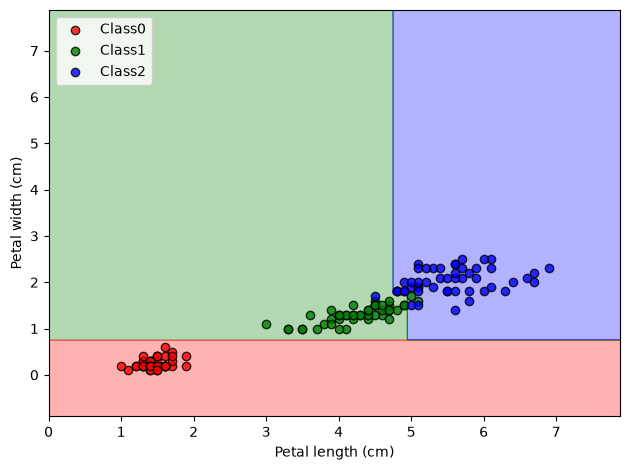

In [21]:
plot_decision_regions(X_combined, y_combined, classifier = tree_model, test_idx = range(105,150))
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')

plt.legend(loc ='upper left')
plt.tight_layout()
plt.show()